In [ ]:
# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Sequential
from tensorflow.keras.models import load_model
from tensorflow.keras.applications import VGG16
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Data handling
import numpy as np
import os
import random

# Image processing & visualization
import matplotlib.pyplot as plt
from PIL import Image

# Evaluation metrics
from sklearn.metrics import classification_report, confusion_matrix

import seaborn as sns

In [ ]:
import zipfile

zip_path = "/content/drive/MyDrive/Ai and Ml/flower.zip"
extract_path = "dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction completed successfully")

Extraction completed successfully


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Data Understanding, Analysis, Visualization and Cleaning

Path and basic info

In [ ]:
import os
train_dir = "dataset/flowers/train"
val_dir = "dataset/flowers/val"
test_dir = "dataset/flowers/test"

class_names = sorted(os.listdir(train_dir))
print("Classes:", class_names)

Classes: ['daisy', 'dandelion', 'lily', 'orchid', 'rose', 'sunflower', 'tulip']


Counting total image

In [ ]:
def count_images(folder):
    total = 0
    for cls in os.listdir(folder):
        total += len(os.listdir(os.path.join(folder, cls)))
    return total

train_count = count_images(train_dir)
val_count = count_images(val_dir)
test_count = count_images(test_dir)

print("Train:", train_count)
print("Validation:", val_count)
print("Test:", test_count)
print("Total:", train_count + val_count + test_count)

Train: 8069
Validation: 2306
Test: 1156
Total: 11531


Class Distribution

In [ ]:
class_counts = {}

for cls in class_names:
    path = os.path.join(train_dir, cls)
    class_counts[cls] = len(os.listdir(path))

print(class_counts)

{'daisy': 1231, 'dandelion': 1046, 'lily': 1132, 'orchid': 1295, 'rose': 1042, 'sunflower': 1199, 'tulip': 1124}


Distribution graph

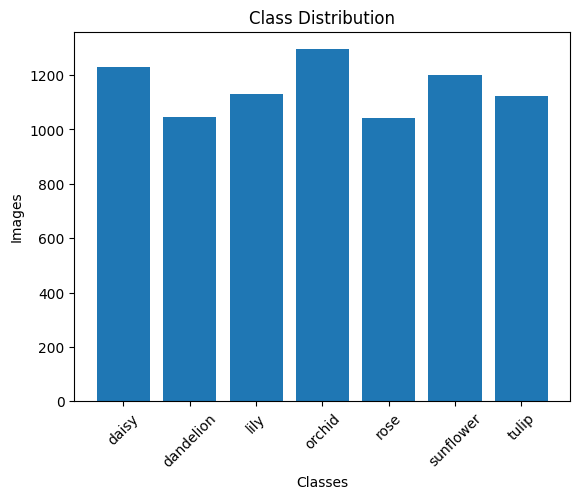

In [ ]:
import matplotlib.pyplot as plt

plt.bar(class_counts.keys(), class_counts.values())
plt.xticks(rotation=45)
plt.title("Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Images")
plt.show()

Visualizing dataset images

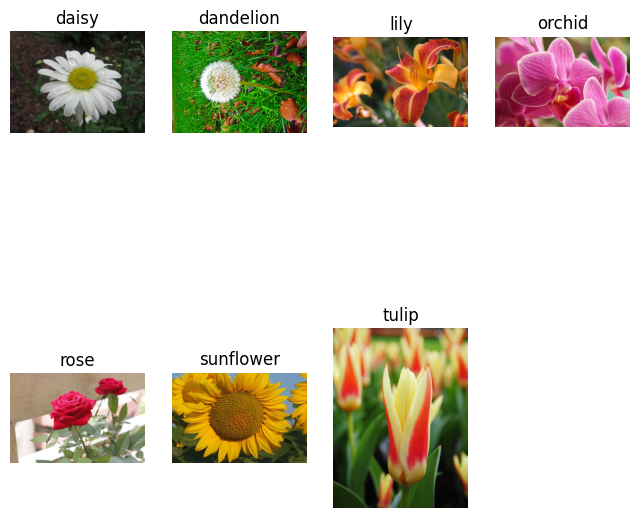

In [ ]:
import random
from PIL import Image

plt.figure(figsize=(8,8))

for i, cls in enumerate(class_names):
    path = os.path.join(train_dir, cls)
    img = random.choice(os.listdir(path))

    plt.subplot(2,4,i+1)
    plt.imshow(Image.open(os.path.join(path,img)))
    plt.title(cls)
    plt.axis("off")

plt.show()

Loading dataset

In [ ]:
import tensorflow as tf

img_height = 224
img_width = 224
batch_size = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    image_size=(img_height,img_width),
    batch_size=batch_size
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    val_dir,
    image_size=(img_height,img_width),
    batch_size=batch_size
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=(img_height,img_width),
    batch_size=batch_size
)

Found 8069 files belonging to 7 classes.
Found 2306 files belonging to 7 classes.
Found 1156 files belonging to 7 classes.


Normalization

In [ ]:
rescale = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x,y:(rescale(x),y))
val_ds = val_ds.map(lambda x,y:(rescale(x),y))
test_ds = test_ds.map(lambda x,y:(rescale(x),y))

Data Augmentation

In [ ]:
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

Showing augmented images

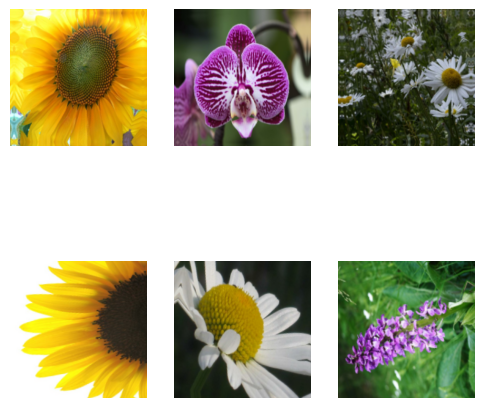

In [ ]:
for images, _ in train_ds.take(1):
    augmented = data_augmentation(images)

    plt.figure(figsize=(6,6))
    for i in range(6):
        plt.subplot(2,3,i+1)
        plt.imshow(augmented[i].numpy())
        plt.axis("off")

    plt.show()

# Baseline Model

In [ ]:
from tensorflow.keras import Sequential

baseline_model = Sequential([

    data_augmentation,

    layers.Conv2D(32,(3,3),activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128,(3,3),activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128,activation='relu'),
    layers.Dense(64,activation='relu'),
    layers.Dense(32,activation='relu'),

    layers.Dense(len(class_names),activation='softmax')
])

baseline_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (32, 224, 224, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (32, 222, 222, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (32, 111, 111, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (32, 109, 109, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (32, 54, 54, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (32, 52, 52, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (32, 26, 26, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (32, 86528)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (32, 128)              │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (32, 64)               │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (32, 32)               │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (32, 7)                │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,179,527 (42.65 MB)

 Trainable params: 11,179,527 (42.65 MB)

 Non-trainable params: 0 (0.00 B)

Training Baseline

In [ ]:
baseline_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

In [ ]:
history_base = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,                 # higher limit
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
253/253 ━━━━━━━━━━━━━━━━━━━━ 30s 94ms/step - accuracy: 0.6568 - loss: 0.9726 - val_accuracy: 0.7715 - val_loss: 0.6632
Epoch 2/30
253/253 ━━━━━━━━━━━━━━━━━━━━ 23s 91ms/step - accuracy: 0.7846 - loss: 0.6376 - val_accuracy: 0.7780 - val_loss: 0.6517
Epoch 3/30
253/253 ━━━━━━━━━━━━━━━━━━━━ 21s 83ms/step - accuracy: 0.8126 - loss: 0.5562 - val_accuracy: 0.8361 - val_loss: 0.4744
Epoch 4/30
253/253 ━━━━━━━━━━━━━━━━━━━━ 28s 109ms/step - accuracy: 0.8431 - loss: 0.4644 - val_accuracy: 0.8352 - val_loss: 0.4803
Epoch 5/30
253/253 ━━━━━━━━━━━━━━━━━━━━ 23s 91ms/step - accuracy: 0.8617 - loss: 0.4086 - val_accuracy: 0.8777 - val_loss: 0.3820
Epoch 6/30
253/253 ━━━━━━━━━━━━━━━━━━━━ 21s 83ms/step - accuracy: 0.8826 - loss: 0.3484 - val_accuracy: 0.8634 - val_loss: 0.4112
Epoch 7/30
253/253 ━━━━━━━━━━━━━━━━━━━━ 28s 110ms/step - accuracy: 0.8877 - loss: 0.3371 - val_accuracy: 0.8881 - val_loss: 0.3451
Epoch 8/30
253/253 ━━━━━━━━━━━━━━━━━━━━ 28s 110ms/step - accuracy: 0.9020 - loss: 0.2992

The baseline model showed steady improvement in both training and validation accuracy during the initial epochs. The best performance was achieved around epoch 14, after which validation accuracy plateaued while training accuracy continued to increase, indicating the onset of overfitting. Early stopping was triggered at epoch 19, and the model weights from the best epoch were restored. This ensured optimal performance while preventing unnecessary training and overfitting.

Visualization

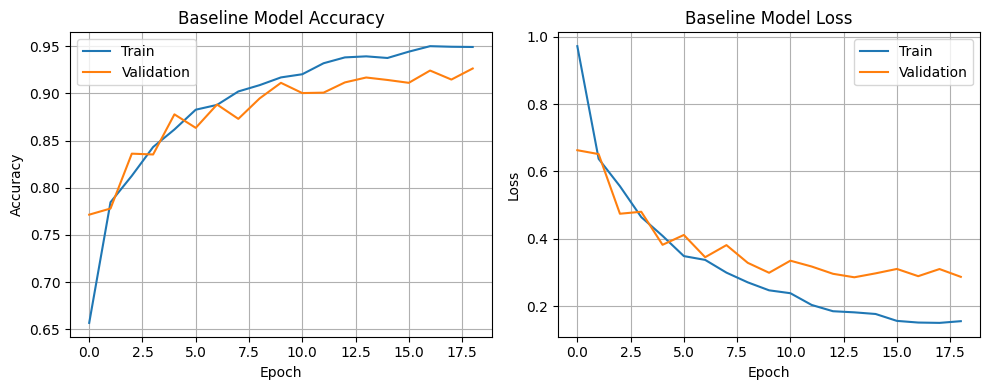

In [ ]:
import matplotlib.pyplot as plt

epochs_range = range(len(history_base.history['accuracy']))

plt.figure(figsize=(10,4))

# Accuracy
plt.subplot(1,2,1)
plt.plot(epochs_range, history_base.history['accuracy'], label='Train')
plt.plot(epochs_range, history_base.history['val_accuracy'], label='Validation')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Baseline Model Accuracy")
plt.legend()
plt.grid()

# Loss
plt.subplot(1,2,2)
plt.plot(epochs_range, history_base.history['loss'], label='Train')
plt.plot(epochs_range, history_base.history['val_loss'], label='Validation')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline Model Loss")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

The baseline model demonstrates steady improvement in both training and validation accuracy, reaching approximately 92–93% validation accuracy. The loss curves show a consistent decrease during the initial epochs, indicating effective learning. However, after mid-training, validation loss stabilizes while training loss continues to decrease, suggesting the onset of slight overfitting. The close alignment between training and validation curves indicates good generalization, and early stopping ensures that the model retains optimal performance

In [ ]:
test_loss, test_acc = baseline_model.evaluate(test_ds)

print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - accuracy: 0.9040 - loss: 0.3981
Test Accuracy: 0.9039792418479919
Test Loss: 0.39808279275894165


The baseline model achieved a test accuracy of around 90.4%, which indicates that the model performs well on unseen data. This shows that the model has successfully learned useful features from the training data and is able to generalize reasonably well.

When comparing this with the training and validation results, there is a slight drop in performance from validation (~92–93%) to test (~90%). This small gap suggests that there is mild overfitting, meaning the model has learned the training data slightly better than completely new data. However, the difference is not large, so the model is still considered stable and reliable.

The test loss (~0.39) is also relatively low, which indicates that the model’s predictions are fairly accurate and consistent. Overall, the baseline model provides a strong starting point for the task, achieving good accuracy without being overly complex. However, since there is still a small gap in performance, more advanced models such as deeper CNNs or transfer learning models can be used to further improve the results.

Evaluation

In [ ]:
import numpy as np
from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images, labels in test_ds:
    preds = baseline_model.predict(images)
    preds = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

print(classification_report(y_true, y_pred, target_names=class_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━

The classification report shows that the baseline model achieves an overall accuracy of around 90%, which indicates good performance on the test dataset. The precision, recall, and F1-scores are generally high across most classes, suggesting that the model is able to correctly classify most flower categories.
For classes like sunflower, dandelion, and daisy, the model performs very well, with F1-scores close to or above 0.94. This means these classes are easier for the model to distinguish, likely because they have more distinct visual features.

However, some classes such as rose and orchid have slightly lower performance. For example, the recall for rose is around 0.76, which indicates that the model sometimes fails to correctly identify rose images. This could be due to similarities between roses and other flower types or variations within the class.

The macro average and weighted average F1-scores are both around 0.90, which shows that the model performs consistently across all classes without significant bias toward any particular class. Overall, the baseline model demonstrates strong and balanced performance, but there is still room for improvement, especially for classes with lower recall. More advanced models can help improve these weaker areas and achieve higher overall accuracy.

# Deeper Model

Deep model

In [ ]:
from tensorflow.keras import Sequential

deep_model = Sequential([

    data_augmentation,

    layers.Conv2D(32,(3,3),activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    layers.Conv2D(64,(3,3),activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    layers.Conv2D(128,(3,3),activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    layers.Conv2D(256,(3,3),activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    layers.Flatten(),

    layers.Dense(256,activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),

    layers.Dense(len(class_names),activation='softmax')
])

deep_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (32, 224, 224, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (32, 222, 222, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (32, 222, 222, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (32, 111, 111, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (32, 111, 111, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (32, 109, 109, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (32, 109, 109, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (32, 54, 54, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (32, 54, 54, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (32, 52, 52, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (32, 52, 52, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (32, 26, 26, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (32, 26, 26, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (32, 24, 24, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (32, 24, 24, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (32, 12, 12, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (32, 12, 12, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (32, 36864)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (32, 256)              │     9,437,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (32, 256)              │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (32, 256)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (32, 7)                │         1,799 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 9,830,599 (37.50 MB)

 Trainable params: 9,829,127 (37.50 MB)

 Non-trainable params: 1,472 (5.75 KB)

Training the deep model

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Save best model
checkpoint = ModelCheckpoint(
    "best_deep_model.keras",
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

# Stop early if no improvement
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,                 # stops if no improvement for 5 epochs
    restore_best_weights=True,
    verbose=1
)

# Compile model
deep_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train model
history_deep = deep_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,                  # max limit
    callbacks=[checkpoint, early_stop],
    verbose=1
)

Epoch 1/30
253/253 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accuracy: 0.5723 - loss: 1.3693
Epoch 1: val_loss improved from None to 4.83170, saving model to best_deep_model.keras

Epoch 1: finished saving model to best_deep_model.keras
253/253 ━━━━━━━━━━━━━━━━━━━━ 50s 177ms/step - accuracy: 0.6356 - loss: 1.1533 - val_accuracy: 0.1652 - val_loss: 4.8317
Epoch 2/30
252/253 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.7308 - loss: 0.7920
Epoch 2: val_loss improved from 4.83170 to 1.01729, saving model to best_deep_model.keras

Epoch 2: finished saving model to best_deep_model.keras
253/253 ━━━━━━━━━━━━━━━━━━━━ 44s 173ms/step - accuracy: 0.7415 - loss: 0.7665 - val_accuracy: 0.6609 - val_loss: 1.0173
Epoch 3/30
252/253 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.7855 - loss: 0.6337
Epoch 3: val_loss did not improve from 1.01729
253/253 ━━━━━━━━━━━━━━━━━━━━ 81s 171ms/step - accuracy: 0.7901 - loss: 0.6197 - val_accuracy: 0.6409 - val_loss: 1.2568
Epoch 4/30
252/253 ━━━━━━━━━━━━━━━━━━━

The deeper CNN model demonstrated significantly improved performance compared to the baseline model. Although the initial training epochs showed instability with high validation loss, the model quickly stabilized and achieved strong performance. The best results were obtained around epoch 20, with validation accuracy reaching approximately 96%. After this point, validation performance began to fluctuate, indicating the onset of overfitting. Early stopping was triggered at epoch 25, and the model weights from the best epoch were restored, ensuring optimal performance.

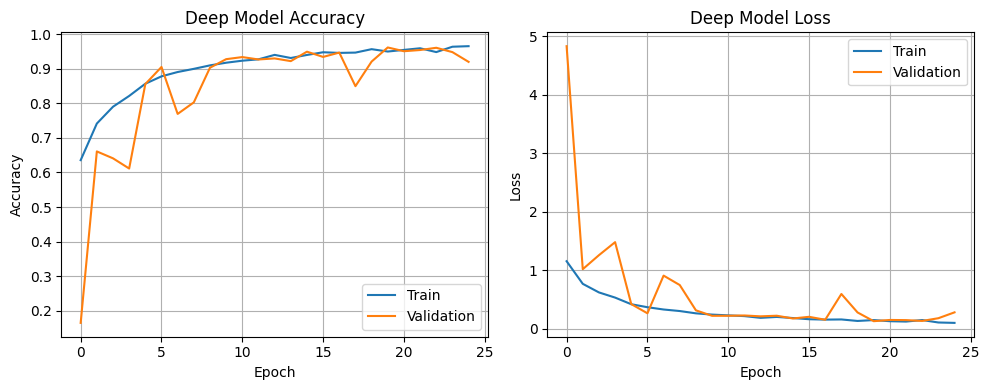

In [ ]:
import matplotlib.pyplot as plt

epochs_range = range(len(history_deep.history['accuracy']))

plt.figure(figsize=(10,4))

# Accuracy
plt.subplot(1,2,1)
plt.plot(epochs_range, history_deep.history['accuracy'], label='Train')
plt.plot(epochs_range, history_deep.history['val_accuracy'], label='Validation')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Deep Model Accuracy")
plt.legend()
plt.grid()

# Loss
plt.subplot(1,2,2)
plt.plot(epochs_range, history_deep.history['loss'], label='Train')
plt.plot(epochs_range, history_deep.history['val_loss'], label='Validation')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Deep Model Loss")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

The deep model shows rapid improvement in both training and validation accuracy, achieving approximately 96–97% accuracy. Although validation performance is initially unstable, it quickly stabilizes after a few epochs. The loss curves show a sharp decrease, indicating effective learning, followed by minor fluctuations that suggest slight overfitting. Overall, the model demonstrates strong performance and better feature learning compared to the baseline model.

In [ ]:
test_loss, test_acc = deep_model.evaluate(test_ds)

print("Deep Model Test Accuracy:", test_acc)
print("Deep Model Test Loss:", test_loss)

37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - accuracy: 0.9576 - loss: 0.1266
Deep Model Test Accuracy: 0.9576124548912048
Deep Model Test Loss: 0.12663786113262177


The deep CNN model achieved a test accuracy of approximately 95.8%, demonstrating a significant improvement over the baseline model. The low test loss indicates that the model makes accurate and confident predictions. The close alignment between training, validation, and test accuracy suggests that the model generalizes well and does not suffer from major overfitting. This highlights the effectiveness of deeper architectures and regularization techniques in improving model performance.

In [ ]:
import numpy as np
from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images, labels in test_ds:
    preds = deep_model.predict(images)
    preds = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

print(classification_report(y_true, y_pred, target_names=class_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 629ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/

The deep model achieved an overall accuracy of 96%, with consistently high precision, recall, and F1-scores across all classes. Compared to the baseline model, there is a significant improvement in performance, particularly in recall and overall balance. Most classes achieved F1-scores above 0.95, indicating reliable classification. Slightly lower performance was observed for the rose class, likely due to visual similarities with other flowers. The close alignment between macro and weighted averages confirms that the model is not biased toward any specific class.

# Experimentation

Comparision of the optimizer

In [ ]:
def build_deep_model():
    return Sequential([

        data_augmentation,

        layers.Conv2D(32,(3,3),activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Dropout(0.25),

        layers.Conv2D(64,(3,3),activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Dropout(0.25),

        layers.Conv2D(128,(3,3),activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Dropout(0.25),

        layers.Conv2D(256,(3,3),activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Dropout(0.25),

        layers.Flatten(),

        layers.Dense(256,activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),

        layers.Dense(len(class_names),activation='softmax')
    ])

Training with SGD

In [ ]:
# SGD (tuned)
model_sgd = build_deep_model()

from tensorflow.keras.optimizers import SGD

optimizer_sgd = SGD(
    learning_rate=0.01,
    momentum=0.9,
    nesterov=True
)

model_sgd.compile(
    optimizer=optimizer_sgd,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_sgd = model_sgd.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
253/253 ━━━━━━━━━━━━━━━━━━━━ 46s 170ms/step - accuracy: 0.6071 - loss: 1.1803 - val_accuracy: 0.6093 - val_loss: 1.0725
Epoch 2/10
253/253 ━━━━━━━━━━━━━━━━━━━━ 80s 163ms/step - accuracy: 0.6948 - loss: 0.8908 - val_accuracy: 0.6110 - val_loss: 1.1693
Epoch 3/10
253/253 ━━━━━━━━━━━━━━━━━━━━ 41s 163ms/step - accuracy: 0.7300 - loss: 0.8136 - val_accuracy: 0.7246 - val_loss: 0.8109
Epoch 4/10
253/253 ━━━━━━━━━━━━━━━━━━━━ 82s 164ms/step - accuracy: 0.7619 - loss: 0.7031 - val_accuracy: 0.7138 - val_loss: 0.8986
Epoch 5/10
253/253 ━━━━━━━━━━━━━━━━━━━━ 41s 163ms/step - accuracy: 0.7751 - loss: 0.6549 - val_accuracy: 0.8101 - val_loss: 0.5661
Epoch 6/10
253/253 ━━━━━━━━━━━━━━━━━━━━ 41s 162ms/step - accuracy: 0.8012 - loss: 0.5928 - val_accuracy: 0.8192 - val_loss: 0.5231
Epoch 7/10
253/253 ━━━━━━━━━━━━━━━━━━━━ 42s 164ms/step - accuracy: 0.8053 - loss: 0.5816 - val_accuracy: 0.8448 - val_loss: 0.4609
Epoch 8/10
253/253 ━━━━━━━━━━━━━━━━━━━━ 83s 168ms/step - accuracy: 0.8270 - loss: 0

Training with Adam

In [ ]:
model_adam = build_deep_model()

model_adam.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_adam = model_adam.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
253/253 ━━━━━━━━━━━━━━━━━━━━ 48s 174ms/step - accuracy: 0.6211 - loss: 1.1687 - val_accuracy: 0.2385 - val_loss: 2.8009
Epoch 2/10
253/253 ━━━━━━━━━━━━━━━━━━━━ 44s 172ms/step - accuracy: 0.7355 - loss: 0.7999 - val_accuracy: 0.7450 - val_loss: 0.7384
Epoch 3/10
253/253 ━━━━━━━━━━━━━━━━━━━━ 84s 179ms/step - accuracy: 0.7842 - loss: 0.6401 - val_accuracy: 0.7806 - val_loss: 0.6566
Epoch 4/10
253/253 ━━━━━━━━━━━━━━━━━━━━ 50s 196ms/step - accuracy: 0.8229 - loss: 0.5180 - val_accuracy: 0.8170 - val_loss: 0.5275
Epoch 5/10
253/253 ━━━━━━━━━━━━━━━━━━━━ 45s 178ms/step - accuracy: 0.8529 - loss: 0.4316 - val_accuracy: 0.8886 - val_loss: 0.3450
Epoch 6/10
253/253 ━━━━━━━━━━━━━━━━━━━━ 81s 174ms/step - accuracy: 0.8738 - loss: 0.3791 - val_accuracy: 0.7958 - val_loss: 0.6977
Epoch 7/10
253/253 ━━━━━━━━━━━━━━━━━━━━ 82s 173ms/step - accuracy: 0.8864 - loss: 0.3397 - val_accuracy: 0.7823 - val_loss: 0.9741
Epoch 8/10
253/253 ━━━━━━━━━━━━━━━━━━━━ 44s 172ms/step - accuracy: 0.9058 - loss: 0

Comparision between SGD and Adam

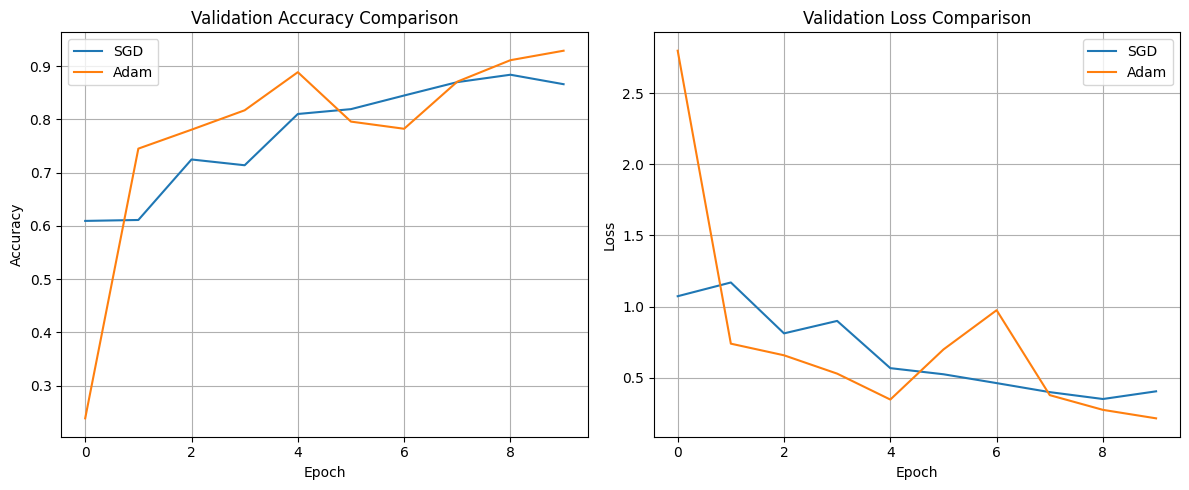

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Accuracy comparison
plt.subplot(1,2,1)
plt.plot(history_sgd.history['val_accuracy'], label='SGD')
plt.plot(history_adam.history['val_accuracy'], label='Adam')
plt.title("Validation Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()

# Loss comparison
plt.subplot(1,2,2)
plt.plot(history_sgd.history['val_loss'], label='SGD')
plt.plot(history_adam.history['val_loss'], label='Adam')
plt.title("Validation Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

The graphs compare the performance of two optimizers, SGD and Adam, in terms of validation accuracy and validation loss over multiple epochs.

In the accuracy graph, Adam starts with a lower accuracy but improves very rapidly within the first few epochs. It quickly surpasses SGD and reaches a higher final accuracy of around 92–93%. On the other hand, SGD starts with a higher initial accuracy but improves more gradually and stabilizes at a lower value of around 87–88%. This shows that Adam is able to learn faster and achieve better performance within fewer epochs.

In the loss graph, Adam shows a sharp decrease in validation loss at the beginning, indicating fast convergence. Although there is a slight fluctuation in the middle of training, the overall trend shows that Adam achieves a lower final loss compared to SGD. In contrast, SGD reduces loss more steadily but at a slower rate and remains higher than Adam throughout most of the training process.Overall, Adam performs better than SGD in this task as it converges faster and achieves higher accuracy with lower loss. SGD, however, provides more stable but slower learning.

The experiment highlights that optimizer performance depends significantly on hyperparameter tuning, as SGD required careful adjustment to achieve competitive results, whereas Adam performed well with minimal tuning.

Result from above

In [ ]:
print("SGD Final Val Accuracy:", history_sgd.history['val_accuracy'][-1])
print("Adam Final Val Accuracy:", history_adam.history['val_accuracy'][-1])

SGD Final Val Accuracy: 0.8660017251968384
Adam Final Val Accuracy: 0.9288811683654785


The optimizer comparison shows that both SGD and Adam are capable of achieving good performance on the dataset, but their efficiency and final results differ. After tuning, SGD achieved a validation accuracy of approximately 86.6%, demonstrating stable and gradual learning. However, Adam outperformed SGD, reaching a higher validation accuracy of around 92.9% and converging much faster during training.

This indicates that while SGD can perform reasonably well with proper tuning of hyperparameters such as learning rate and momentum, it requires more effort to achieve competitive results. In contrast, Adam performs well with minimal tuning due to its adaptive learning rate mechanism, allowing it to learn faster and reach better performance.

Overall, Adam is more suitable for this task as it provides higher accuracy and faster convergence, while SGD offers more stable but slower learning.

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, Sequential
import tensorflow as tf

In [ ]:
base_model = VGG16(
    weights='imagenet',
    include_top=False,   # remove original classifier
    input_shape=(224,224,3)
)

In [ ]:
for layer in base_model.layers:
    layer.trainable = False

In [ ]:
transfer_model = Sequential([

    base_model,

    layers.Flatten(),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(len(class_names), activation='softmax')
])

transfer_model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,139,271 (80.64 MB)

 Trainable params: 6,424,583 (24.51 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
transfer_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_vgg16_model.keras",
    monitor='val_loss',
    save_best_only=True
)

In [ ]:
history_vgg = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/10
253/253 ━━━━━━━━━━━━━━━━━━━━ 65s 244ms/step - accuracy: 0.8129 - loss: 0.5932 - val_accuracy: 0.9462 - val_loss: 0.1532
Epoch 2/10
253/253 ━━━━━━━━━━━━━━━━━━━━ 57s 223ms/step - accuracy: 0.9183 - loss: 0.2444 - val_accuracy: 0.9649 - val_loss: 0.1081
Epoch 3/10
253/253 ━━━━━━━━━━━━━━━━━━━━ 64s 253ms/step - accuracy: 0.9434 - loss: 0.1622 - val_accuracy: 0.9601 - val_loss: 0.1138
Epoch 4/10
253/253 ━━━━━━━━━━━━━━━━━━━━ 57s 226ms/step - accuracy: 0.9482 - loss: 0.1509 - val_accuracy: 0.9666 - val_loss: 0.1001
Epoch 5/10
253/253 ━━━━━━━━━━━━━━━━━━━━ 55s 219ms/step - accuracy: 0.9510 - loss: 0.1366 - val_accuracy: 0.9575 - val_loss: 0.1324
Epoch 6/10
253/253 ━━━━━━━━━━━━━━━━━━━━ 56s 220ms/step - accuracy: 0.9465 - loss: 0.1463 - val_accuracy: 0.9631 - val_loss: 0.1098
Epoch 7/10
253/253 ━━━━━━━━━━━━━━━━━━━━ 56s 220ms/step - accuracy: 0.9555 - loss: 0.1215 - val_accuracy: 0.9670 - val_loss: 0.1114
Epoch 8/10
253/253 ━━━━━━━━━━━━━━━━━━━━ 56s 223ms/step - accuracy: 0.9597 - loss: 0

The transfer learning model using VGG16 achieved the highest performance among all models, with validation accuracy reaching approximately 97%. The model converged very quickly within the first few epochs, with significant improvements observed as early as epoch 2–4, demonstrating the effectiveness of pre-trained features learned from ImageNet. Compared to models trained from scratch, VGG16 provides both higher accuracy and more stable learning, while requiring fewer training epochs.

The training and validation curves remain closely aligned throughout, indicating good generalization and minimal overfitting. Although minor fluctuations are observed, the overall trend shows consistent improvement, with the best performance achieved at the final epoch.

In [ ]:
base_model.trainable = True

# Freeze most layers, unfreeze last few
for layer in base_model.layers[:-4]:
    layer.trainable = False

In [ ]:
transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_finetune = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stop]
)

Epoch 1/10
253/253 ━━━━━━━━━━━━━━━━━━━━ 63s 239ms/step - accuracy: 0.9757 - loss: 0.0698 - val_accuracy: 0.9766 - val_loss: 0.0860
Epoch 2/10
253/253 ━━━━━━━━━━━━━━━━━━━━ 56s 220ms/step - accuracy: 0.9777 - loss: 0.0603 - val_accuracy: 0.9783 - val_loss: 0.0834
Epoch 3/10
253/253 ━━━━━━━━━━━━━━━━━━━━ 56s 220ms/step - accuracy: 0.9820 - loss: 0.0527 - val_accuracy: 0.9783 - val_loss: 0.0819
Epoch 4/10
253/253 ━━━━━━━━━━━━━━━━━━━━ 56s 220ms/step - accuracy: 0.9824 - loss: 0.0461 - val_accuracy: 0.9779 - val_loss: 0.0820
Epoch 5/10
253/253 ━━━━━━━━━━━━━━━━━━━━ 56s 220ms/step - accuracy: 0.9850 - loss: 0.0438 - val_accuracy: 0.9796 - val_loss: 0.0829
Epoch 6/10
253/253 ━━━━━━━━━━━━━━━━━━━━ 56s 221ms/step - accuracy: 0.9828 - loss: 0.0422 - val_accuracy: 0.9788 - val_loss: 0.0836
Epoch 7/10
253/253 ━━━━━━━━━━━━━━━━━━━━ 56s 221ms/step - accuracy: 0.9848 - loss: 0.0436 - val_accuracy: 0.9788 - val_loss: 0.0838
Epoch 8/10
253/253 ━━━━━━━━━━━━━━━━━━━━ 56s 220ms/step - accuracy: 0.9840 - loss: 0

Fine-tuning the pre-trained VGG16 model further improved performance, increasing validation accuracy to approximately 97.5–98%. By unfreezing the top layers of the convolutional base, the model was able to adapt previously learned features more effectively to the flower dataset, resulting in slightly better classification performance.

The model converged very quickly, with high accuracy achieved within the first few epochs. After around epoch 3–5, validation accuracy plateaued while training accuracy continued to increase slightly. This indicates the beginning of minor overfitting, although the gap between training and validation performance remains small.

Compared to feature extraction, the improvement from fine-tuning is relatively modest, suggesting that the pre-trained model was already highly effective for this task. This highlights that fine-tuning provides incremental gains rather than significant improvements, especially when the dataset is not highly complex. Overall, fine-tuning enhances performance and allows better adaptation to the dataset, but it must be applied carefully, as excessive training can lead to overfitting without substantial benefits.

In [ ]:
test_loss, test_acc = transfer_model.evaluate(test_ds)

print("Test Accuracy:", test_acc)

37/37 ━━━━━━━━━━━━━━━━━━━━ 9s 250ms/step - accuracy: 0.9697 - loss: 0.1010
Test Accuracy: 0.9697231650352478


The fine-tuned VGG16 model achieved a test accuracy of approximately 96.9%, demonstrating excellent generalization to unseen data. The close alignment between training, validation, and test performance indicates that the model is well-regularized and does not suffer from significant overfitting. Compared to models trained from scratch, transfer learning significantly improved performance and efficiency, making it the most effective approach for this task.
The strong test performance confirms that transfer learning not only improves accuracy but also enhances model generalization compared to training from scratch.

In [ ]:
import numpy as np
from sklearn.metrics import classification_report

y_true, y_pred = [], []

for images, labels in test_ds:
    preds = transfer_model.predict(images)
    preds = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

print(classification_report(y_true, y_pred, target_names=class_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

The classification report demonstrates excellent model performance, achieving an overall accuracy of 97%. The precision, recall, and F1-scores are consistently high across all classes, indicating balanced and reliable classification. Classes such as dandelion and tulip achieved the highest scores due to their distinct visual features, while slightly lower performance was observed for rose, likely due to higher intra-class variation. The close alignment between macro and weighted averages confirms that the model does not exhibit bias toward any specific class.

The consistently high F1-scores across all classes indicate that the model generalizes well and is not biased, which is a key indicator of a robust classification system.

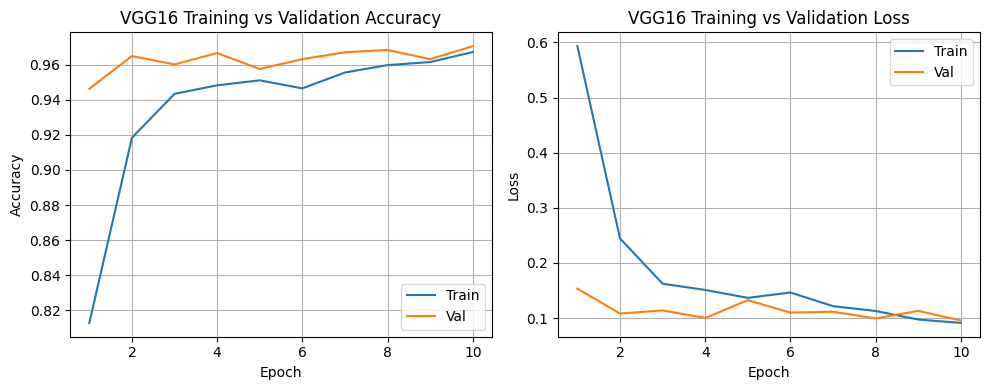

In [ ]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(history_vgg.history['accuracy']) + 1)

plt.figure(figsize=(10,4))

# Accuracy
plt.subplot(1,2,1)
plt.plot(epochs_range, history_vgg.history['accuracy'], label='Train')
plt.plot(epochs_range, history_vgg.history['val_accuracy'], label='Val')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("VGG16 Training vs Validation Accuracy")
plt.legend()
plt.grid()

# Loss
plt.subplot(1,2,2)
plt.plot(epochs_range, history_vgg.history['loss'], label='Train')
plt.plot(epochs_range, history_vgg.history['val_loss'], label='Val')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("VGG16 Training vs Validation Loss")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

The graphs illustrate the performance of the VGG16 model by comparing training and validation accuracy and loss across epochs.

In the accuracy graph, both training and validation accuracy increase rapidly during the initial epochs, indicating that the model quickly learns meaningful features from the dataset. The validation accuracy starts high (around 94–95%) and stabilizes between 96–97%, while the training accuracy gradually increases and closely matches the validation curve. The small gap between the two curves suggests that the model generalizes well and does not exhibit significant overfitting.

In the loss graph, both training and validation loss decrease sharply in the early epochs and then stabilize over time. The validation loss remains relatively low and consistent (around 0.10–0.12), indicating strong performance on unseen data. Minor fluctuations are observed, but there are no major spikes or divergence between the curves, which confirms stable and well-controlled training. Overall, the graphs demonstrate that the VGG16 model converges quickly, achieves high accuracy within a few epochs, and maintains a good balance between training and validation performance. This indicates effective feature learning and strong generalization capability.